# Session / plane ROI SNR metrics

This notebook follows the loading workflow in `DataLoader.ipynb` and calculates two metric families for every ROI in one plane:

1. **Robust event SNR**: `(P95(dF/F) - median(dF/F)) / robust fast-residual noise SD`. This is the primary amplitude-to-noise QC metric.
2. **Exceptional-event fitness** adapted from `evaluate_components.py`: the minimum log probability of observing `N` consecutive high samples under a lower-tail noise model. More-negative fitness indicates stronger exceptional events; `exceptional_event_score = -fitness` is provided so larger values indicate stronger events.

`GAUSSIAN_SIGMA` is measured in imaging frames, not seconds.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import mesoscope_qc_pipeline as qc
import mesoscope_qc_reports as qcr
from mesoscope_snr import calculate_roi_snr_metrics

# The report module selects the noninteractive Agg backend for PDF files.
# Restore inline rendering for this notebook after importing it.
%matplotlib inline


## Configuration

`SESSION_SOURCE` may be a downloaded local NWB path or an AIND processed-session S3 path. Set `MAX_FRAMES = None` to calculate metrics from the complete trace. Using a frame limit changes percentile, noise, and exceptional-event estimates.

In [2]:
SESSION_SOURCE = qcr.DEFAULT_SESSION_SOURCE
PLANE = "VISp_0"
MAX_FRAMES = None

GAUSSIAN_SIGMA = 3.0
CONSECUTIVE_SAMPLES = 5
EXCEPTIONAL_ROBUST_STD = False

OUTPUT_DIR = REPO_ROOT / "outputs" / "snr_metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
session = qcr.open_session(SESSION_SOURCE)
try:
    nwb = session["nwb"]
    available_planes = list(session["planes"])
    if PLANE not in available_planes:
        raise KeyError(f"Plane {PLANE!r} not found. Available planes: {available_planes}")

    proc = nwb.processing[PLANE]
    dff_series = qc.get_timeseries_from_proc(
        proc,
        [("dff_timeseries", "dff_timeseries"), ("dff_timeseries",)],
    )
    if dff_series is None:
        raise KeyError(f"No dF/F timeseries found for {PLANE}")

    dff, timestamps = qc.load_timeseries_matrix(dff_series, max_frames=MAX_FRAMES)
    roi_metadata = qc.get_roi_metadata_for_plane(nwb, PLANE, load_masks=False).reset_index(drop=True)
    session_id = getattr(nwb, "session_id", None) or str(SESSION_SOURCE).rstrip("/").split("/")[-1]
finally:
    qcr.close_session(session)

print("Session:", session_id)
print("Plane:", PLANE)
print("dF/F shape (time, ROI):", dff.shape)
print("Duration (s):", float(timestamps[-1] - timestamps[0]) if len(timestamps) > 1 else np.nan)


Session: multiplane-ophys_839909_2026-02-20_12-53-27
Plane: VISp_0
dF/F shape (time, ROI): (46303, 345)
Duration (s): 4325.61563


In [4]:
snr_metrics = calculate_roi_snr_metrics(
    dff,
    gaussian_sigma=GAUSSIAN_SIGMA,
    consecutive_samples=CONSECUTIVE_SAMPLES,
    exceptional_robust_std=EXCEPTIONAL_ROBUST_STD,
)
roi_snr = roi_metadata.merge(snr_metrics, on="roi_index", how="right")
roi_snr["session_id"] = session_id
roi_snr["plane"] = PLANE
front_columns = ["session_id", "plane"]
roi_snr = roi_snr[front_columns + [c for c in roi_snr.columns if c not in front_columns]]
roi_snr.head()


,session_id,plane,roi_index,is_soma,is_dendrite,soma_probability,dendrite_probability,roi_area_pix,roi_centroid_x_pix,roi_centroid_y_pix,n_timepoints,n_finite_timepoints,fraction_nan,robust_event_snr,robust_event_signal_amp,robust_event_noise_sd,exceptional_event_fitness,exceptional_event_score,exceptional_event_mode,exceptional_event_noise_sd
0,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,0,True,False,0.605588,2.950430e-06,NaN,NaN,NaN,46303,46303,0.0,2.508266,0.103412,0.041228,-59.369505,59.369505,0.007244,0.044260
1,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,1,True,False,0.958772,1.817942e-06,NaN,NaN,NaN,46303,46303,0.0,2.436051,0.122609,0.050331,-34.783905,34.783905,-0.006986,0.048852
2,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,2,True,False,0.999195,8.940697e-08,NaN,NaN,NaN,46303,46303,0.0,6.105272,1.249140,0.204600,-485.673330,485.673330,-0.008425,0.255120
3,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,3,True,False,0.996062,0.000000e+00,NaN,NaN,NaN,46303,46303,0.0,4.230450,0.336461,0.079533,-169.046346,169.046346,-0.011823,0.092135
4,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,4,False,False,0.286248,4.321337e-06,NaN,NaN,NaN,46303,46303,0.0,3.664228,1.948021,0.531632,-39.709066,39.709066,-0.006191,0.589269


In [5]:
metric_columns = [
    "robust_event_snr",
    "robust_event_signal_amp",
    "robust_event_noise_sd",
    "exceptional_event_fitness",
    "exceptional_event_score",
    "exceptional_event_noise_sd",
]
display(roi_snr[metric_columns].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)


,count,mean,std,min,5%,25%,50%,75%,95%,max
robust_event_snr,345.0,3.396984,1.487276,1.953606,2.075760,2.369015,2.863125,3.849413,6.402561,13.087127
robust_event_signal_amp,345.0,0.260564,0.202536,0.072367,0.104633,0.148400,0.198925,0.302870,0.580149,1.948021
robust_event_noise_sd,345.0,0.077752,0.051319,0.028248,0.039739,0.054291,0.065164,0.082409,0.163286,0.531632
exceptional_event_fitness,345.0,-201.123165,229.360500,-1273.979064,-726.461918,-253.318222,-125.173983,-50.034928,-23.443005,-11.989895
exceptional_event_score,345.0,201.123165,229.360500,11.989895,23.443005,50.034928,125.173983,253.318222,726.461918,1273.979064
exceptional_event_noise_sd,345.0,0.074790,0.052607,0.028336,0.036925,0.051098,0.060956,0.077726,0.151981,0.589269


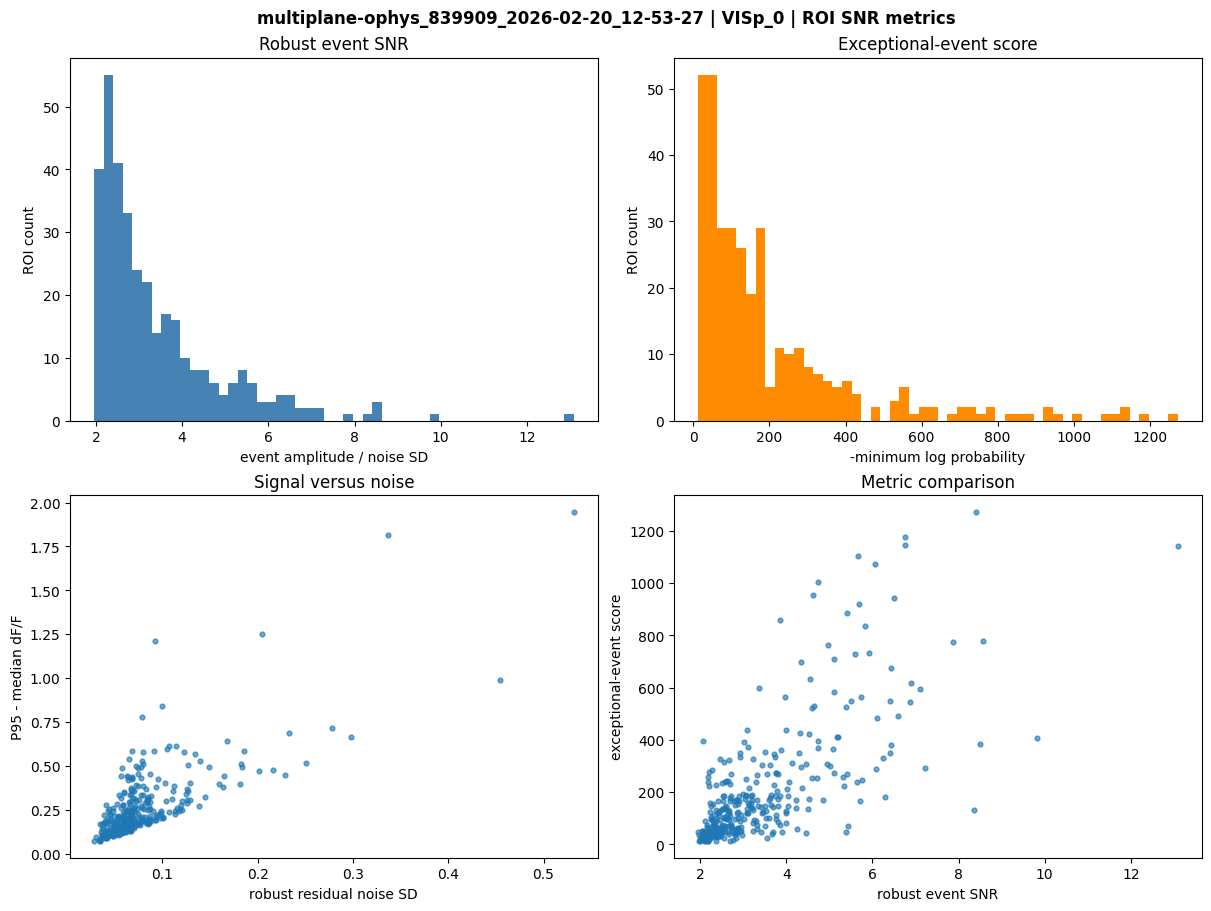

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
fig.suptitle(f"{session_id} | {PLANE} | ROI SNR metrics", fontweight="bold")

axes[0, 0].hist(roi_snr["robust_event_snr"].dropna(), bins=50, color="steelblue")
axes[0, 0].set(title="Robust event SNR", xlabel="event amplitude / noise SD", ylabel="ROI count")

axes[0, 1].hist(roi_snr["exceptional_event_score"].dropna(), bins=50, color="darkorange")
axes[0, 1].set(title="Exceptional-event score", xlabel="-minimum log probability", ylabel="ROI count")

axes[1, 0].scatter(
    roi_snr["robust_event_noise_sd"],
    roi_snr["robust_event_signal_amp"],
    s=12,
    alpha=0.65,
)
axes[1, 0].set(title="Signal versus noise", xlabel="robust residual noise SD", ylabel="P95 - median dF/F")

axes[1, 1].scatter(
    roi_snr["robust_event_snr"],
    roi_snr["exceptional_event_score"],
    s=12,
    alpha=0.65,
)
axes[1, 1].set(title="Metric comparison", xlabel="robust event SNR", ylabel="exceptional-event score")
plt.show()


In [7]:
ranked = roi_snr.sort_values("robust_event_snr", ascending=False)
display(ranked[[
    "roi_index",
    "soma_probability",
    "robust_event_snr",
    "robust_event_signal_amp",
    "robust_event_noise_sd",
    "exceptional_event_fitness",
    "exceptional_event_score",
]].head(25))


,roi_index,soma_probability,robust_event_snr,robust_event_signal_amp,robust_event_noise_sd,exceptional_event_fitness,exceptional_event_score
153,153,0.029021,13.087127,1.213233,0.092704,-1142.489639,1142.489639
287,287,0.999851,9.831788,0.777833,0.079114,-408.732791,408.732791
13,13,0.944349,8.567529,0.587289,0.068548,-777.042497,777.042497
154,154,0.999998,8.487575,0.843454,0.099375,-383.217085,383.217085
80,80,0.999266,8.413885,0.486433,0.057813,-1273.979064,1273.979064
207,207,0.048118,8.351869,0.540618,0.064730,-130.322150,130.322150
59,59,0.999983,7.864872,0.441820,0.056176,-773.172480,773.172480
199,199,0.999266,7.216401,0.577725,0.080057,-293.653453,293.653453
242,242,0.999994,7.108980,0.444355,0.062506,-594.527203,594.527203
147,147,0.999869,6.894971,0.437781,0.063493,-619.458901,619.458901


In [8]:
safe_session = "".join(c if c.isalnum() or c in "._-" else "_" for c in str(session_id))
output_csv = OUTPUT_DIR / f"{safe_session}_{PLANE}_roi_snr_metrics.csv"
roi_snr.to_csv(output_csv, index=False)
print(output_csv)


/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics/multiplane-ophys_839909_2026-02-20_12-53-27_VISp_0_roi_snr_metrics.csv
